In [60]:
! py -3.11 -m pip install selfies > nul 2>&1
! py -3.11 -m pip install openpyxl > nul 2>&1

# Harris Hawks Optimization (HHO) — Corrected Implementation

Fixes applied from algorithmic evaluation:

1. **E0 range**: confirmed `2*random.random()-1` → correct `[-1, 1)`
2. **Exploration q<0.5 branch**: now uses rabbit-energy-guided perch (attraction to prey region) instead of pure self-mutation
3. **Exploitation r<0.5 branches**: Lévy flight now drives the rapid-dive jump (`Y = X_rabbit − E·|X_rabbit − X[i]| + L·levy()`), adapted discretely
4. **W term**: greedy fallback now includes a Lévy-weighted alternative candidate Z in both r<0.5 branches
5. **Fitness normalization**: each term divided by its expected range so MW, donors, acceptors contribute equally
6. **Atom-level mutation**: operates on RDKit `Mol` objects (atom swap, bond edit, fragment add/remove) then canonicalizes — far higher valid-SMILES rate than character-level edits
7. **Fitness cache**: invalid SMILES also cached; initial population evaluated once before the loop

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import math
import random
from typing import Callable, Tuple, List, Optional
import selfies as sf


def levy_flight(dim: int) -> np.ndarray:
    """Lévy flight step vector (Mantegna algorithm, β=1.5)."""
    beta = 1.5
    sigma = (
        math.gamma(1 + beta) * math.sin(math.pi * beta / 2)
        / (math.gamma((1 + beta) / 2) * beta * 2 ** ((beta - 1) / 2))
    ) ** (1 / beta)
    u = np.random.randn(dim) * sigma
    v = np.random.randn(dim)
    return u / np.abs(v) ** (1 / beta)


def levy_scalar() -> float:
    """Single Lévy step magnitude (used to scale discrete jumps)."""
    return float(abs(levy_flight(1)[0]))

iteration: 0
  Itération 1/50 | Meilleur pIC50 = -0.4778 | Molécule = CCC.Clc1ccccc1
Iteration time cons : 0.054998
iteration: 1
  Itération 2/50 | Meilleur pIC50 = -0.3375 | Molécule = CCCCCC.Clc1ccccc1
Iteration time cons : 0.029999
iteration: 2
  Itération 3/50 | Meilleur pIC50 = -0.2227 | Molécule = CCCCCC.Clc1cccc(Cl)c1
Iteration time cons : 0.032
iteration: 3
  Itération 4/50 | Meilleur pIC50 = -0.2227 | Molécule = CCCCCC.Clc1cccc(Cl)c1
Iteration time cons : 0.024
iteration: 4
  Itération 5/50 | Meilleur pIC50 = -0.0479 | Molécule = CCCC(F)CC.Clc1ccc(Cl)c(Cl)c1
Iteration time cons : 0.024001
iteration: 5
  Itération 6/50 | Meilleur pIC50 = -0.0479 | Molécule = CCCC(F)CC.Clc1ccc(Cl)c(Cl)c1
Iteration time cons : 0.028
iteration: 6
  Itération 7/50 | Meilleur pIC50 = -0.0266 | Molécule = CCCCF.Clc1cc(Cl)c(Cl)cc1Cl
Iteration time cons : 0.031006
iteration: 7
  Itération 8/50 | Meilleur pIC50 = -0.0134 | Molécule = CC=CC(C)(F)Cl.Clc1ccc(Cl)c(Cl)c1
Iteration time cons : 0.031993
iterat

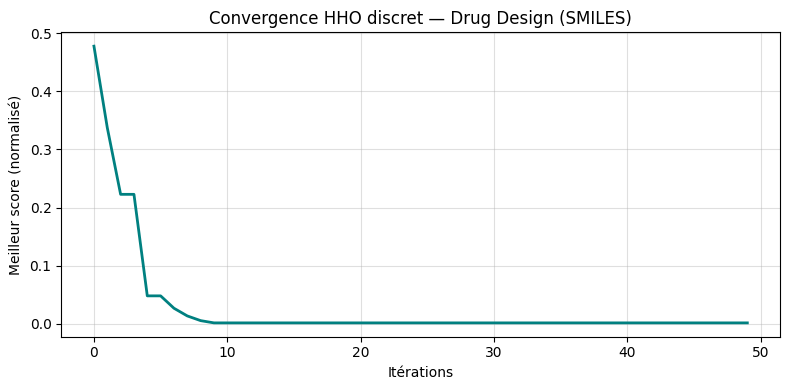

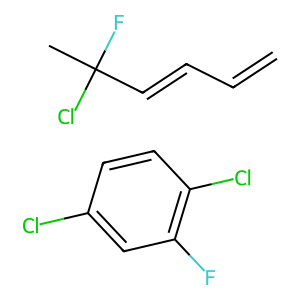

In [28]:
from rdkit import Chem
from rdkit.Chem import Descriptors, AllChem, rdMolDescriptors
from rdkit.Chem.rdchem import RWMol
from IPython.display import display
import time


# ── Atom-level mutation (FIX 6: operates on Mol objects, not raw characters) ──

_ATOM_POOL = [6, 7, 8, 9, 16, 17]  # C N O F S Cl

def _try_canonicalize(mol) -> Optional[str]:
    """Return canonical SMILES if mol is valid, else None."""
    if mol is None:
        return None
    try:
        Chem.SanitizeMol(mol)
        return Chem.MolToSmiles(mol)
    except Exception:
        return None


def atom_mutate(smiles: str, intensity: float) -> str:
    """
    Atom-level mutation: randomly swap atom types, add/remove atoms, or
    toggle bond orders on the RDKit Mol object.
    Returns canonical SMILES of the mutant, or the original if all attempts fail.
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return smiles

    n_atoms = mol.GetNumAtoms()
    n_muts = max(1, int(n_atoms * intensity))

    for _ in range(n_muts):
        action = random.choices(
            ['swap_atom', 'toggle_bond', 'add_atom', 'remove_atom'],
            weights=[0.45, 0.25, 0.20, 0.10]
        )[0]

        rw = RWMol(mol)
        n = rw.GetNumAtoms()
        if n == 0:
            break

        try:
            if action == 'swap_atom':
                idx = random.randint(0, n - 1)
                new_num = random.choice(_ATOM_POOL)
                rw.GetAtomWithIdx(idx).SetAtomicNum(new_num)

            elif action == 'toggle_bond' and rw.GetNumBonds() > 0:
                bond = random.choice(list(rw.GetBonds()))
                current = bond.GetBondTypeAsDouble()
                new_type = (
                    Chem.BondType.DOUBLE if current == 1.0
                    else Chem.BondType.SINGLE
                )
                rw.GetBondWithIdx(bond.GetIdx()).SetBondType(new_type)

            elif action == 'add_atom':
                new_idx = rw.AddAtom(Chem.Atom(random.choice(_ATOM_POOL)))
                anchor = random.randint(0, n - 1)
                rw.AddBond(anchor, new_idx, Chem.BondType.SINGLE)

            elif action == 'remove_atom' and n > 2:
                # Only remove terminal atoms (degree 1) to avoid disconnecting
                terminals = [a.GetIdx() for a in rw.GetAtoms() if a.GetDegree() == 1]
                if terminals:
                    rw.RemoveAtom(random.choice(terminals))

            candidate = _try_canonicalize(rw.GetMol())
            if candidate:
                mol = Chem.MolFromSmiles(candidate)  # update mol for next mutation

        except Exception:
            continue

    result = _try_canonicalize(mol)
    return result if result else smiles


def atom_crossover(smiles1: str, smiles2: str) -> str:
    """
    Fragment-aware crossover: cut both molecules at a random bond and
    swap fragments. Falls back to the original smiles1 if both fail.
    """
    mol1 = Chem.MolFromSmiles(smiles1)
    mol2 = Chem.MolFromSmiles(smiles2)
    if mol1 is None or mol2 is None:
        return smiles1

    for _ in range(8):
        try:
            # Pick a random bond in each molecule to cut
            bonds1 = list(mol1.GetBonds())
            bonds2 = list(mol2.GetBonds())
            if not bonds1 or not bonds2:
                break

            b1 = random.choice(bonds1)
            b2 = random.choice(bonds2)

            frag1 = Chem.FragmentOnBonds(mol1, [b1.GetIdx()], addDummies=False)
            frag2 = Chem.FragmentOnBonds(mol2, [b2.GetIdx()], addDummies=False)

            parts1 = Chem.GetMolFrags(frag1, asMols=True, sanitizeFrags=False)
            parts2 = Chem.GetMolFrags(frag2, asMols=True, sanitizeFrags=False)

            if not parts1 or not parts2:
                continue

            combined = Chem.CombineMols(parts1[0], parts2[-1])
            candidate = _try_canonicalize(combined)
            if candidate:
                return candidate
        except Exception:
            continue

    return smiles1


# ── FIX 5: Normalized fitness ──────────────────────────────────────────────

def smiles_fitness(smiles: str) -> float:
    """
    Normalized fitness: each term scaled to [0, 1] so they contribute equally.
      - MW target 300 Da  → normalized by 300
      - H-donors          → typical max ~5, normalized by 5
      - H-acceptors       → typical max ~10, normalized by 10
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return float('inf')
    mw = Descriptors.MolWt(mol)
    donors = Descriptors.NumHDonors(mol)
    acceptors = Descriptors.NumHAcceptors(mol)
    return abs(mw - 300) / 300.0 + donors / 5.0 + acceptors / 10.0


# ── Lévy-guided discrete jump (FIX 3: encodes the paper's rapid-dive idea) ──

def levy_jump(smiles: str, rabbit: str, E: float) -> str:
    """
    Discrete analogue of: Y = X_rabbit − E · |X_rabbit − X[i]| + L · Lévy()
    The Lévy scalar modulates mutation intensity and whether we start from
    rabbit or from self, mirroring the continuous paper equation.
    """
    L = levy_scalar()  # heavy-tailed step magnitude
    # Lévy scale → intensity in [0.05, 0.6] (clipped to avoid degenerate mutations)
    intensity = min(0.6, max(0.05, 0.1 * L))
    # abs(E) < 0.5 → exploit rabbit closely; abs(E) >= 0.5 → explore around rabbit
    if abs(E) < 0.5:
        return atom_mutate(rabbit, intensity)
    else:
        return atom_mutate(atom_crossover(smiles, rabbit), intensity)


# ── Corrected hho_discrete ─────────────────────────────────────────────────

def hho_discrete(
    obj_func: Callable[[str], float],
    initial_population: List[str],
    max_iter: int = 50
) -> Tuple[str, float, List[float]]:
    """
    Discrete HHO with all algorithmic fixes applied.

    Key changes vs original:
    - Exploration q<0.5: rabbit-energy guided perch (FIX 2)
    - Exploitation r<0.5: Lévy-driven rapid dive (FIX 3)
    - Greedy fallback: includes Lévy-jump candidate W (FIX 4)
    - Atom-level mutation instead of char-level (FIX 6)
    - Fitness uses normalized terms (FIX 5)
    - Rabbit updated inline each step (no one-iteration lag)
    """
    pop_size = len(initial_population)
    X = initial_population.copy()

    rabbit_location = ''
    rabbit_energy = float('inf')
    convergence_curve = []
    time_spent = []
    num_mol_checked = []
    global fitness_cache
    fitness_cache = {}

    # Evaluate initial population once, cache scores
    fitness_vals = [obj_func(s) for s in X]
    for i, f in enumerate(fitness_vals):
        if f < rabbit_energy:
            rabbit_energy = f
            rabbit_location = X[i]

    start = time.time()
    for t in range(max_iter):
        old_cache = len(fitness_cache)
        if t > 0:
            end = time.time()
            print(f"Iteration time cons : {(end - start):.5}")
            time_spent.append((end - start))
            start = time.time()
        
        print("iteration:", t)
        E1 = 2.0 * (1.0 - t / max_iter)

        for i in range(pop_size):
            # E0 ∈ (−1, 1) — confirmed correct range
            E0 = 2.0 * random.random() - 1.0
            E = E1 * E0
            fi = fitness_vals[i]

            if abs(E) >= 1.0:
                # ── Exploration phase ──────────────────────────────────────
                q = random.random()
                if q >= 0.5:
                    # Random tall-tree perch: crossover with a random hawk
                    rand_idx = random.randint(0, pop_size - 1)
                    candidate = atom_mutate(
                        atom_crossover(X[i], X[rand_idx]), intensity=0.3
                    )
                else:
                    # FIX 2: rabbit-energy perch — attracted toward prey region
                    # Paper: X(t+1) = X_rabbit − X_m + rand·(LB + rand·(UB-LB))
                    # Discrete: mutate a crossover between self and rabbit,
                    # scaled by a Lévy step for heavy-tailed exploration
                    L = levy_scalar()
                    intensity = min(0.6, max(0.05, 0.15 * L))
                    candidate = atom_mutate(
                        atom_crossover(X[i], rabbit_location), intensity=intensity
                    )

                fc = obj_func(candidate)
                if fc < fi:
                    X[i] = candidate
                    fitness_vals[i] = fc

            else:
                # ── Exploitation phase ─────────────────────────────────────
                r = random.random()

                if r >= 0.5 and abs(E) >= 0.5:
                    # Soft besiege
                    candidate = atom_mutate(
                        atom_crossover(X[i], rabbit_location), intensity=0.1
                    )
                    fc = obj_func(candidate)
                    if fc < fi:
                        X[i] = candidate
                        fitness_vals[i] = fc

                elif r >= 0.5 and abs(E) < 0.5:
                    # Hard besiege
                    candidate = atom_mutate(rabbit_location, intensity=0.08)
                    fc = obj_func(candidate)
                    if fc < fi:
                        X[i] = candidate
                        fitness_vals[i] = fc

                elif r < 0.5 and abs(E) >= 0.5:
                    # FIX 3+4: Soft besiege with Lévy rapid dive
                    Y = levy_jump(X[i], rabbit_location, E)  # Lévy-guided candidate
                    fy = obj_func(Y)
                    if fy < fi:
                        X[i] = Y
                        fitness_vals[i] = fy
                    else:
                        # W term: another Lévy jump as fallback (paper's Z step)
                        W = levy_jump(rabbit_location, X[i], E)
                        fw = obj_func(W)
                        if fw < fi:
                            X[i] = W
                            fitness_vals[i] = fw

                elif r < 0.5 and abs(E) < 0.5:
                    # FIX 3+4: Hard besiege with Lévy rapid dive
                    Y = levy_jump(X[i], rabbit_location, E)
                    fy = obj_func(Y)
                    if fy < fi:
                        X[i] = Y
                        fitness_vals[i] = fy
                    else:
                        W = atom_mutate(Y, intensity=0.2)  # local refinement
                        fw = obj_func(W)
                        if fw < fi:
                            X[i] = W
                            fitness_vals[i] = fw

            # Inline rabbit update — no one-iteration lag
            if fitness_vals[i] < rabbit_energy:
                rabbit_energy = fitness_vals[i]
                rabbit_location = X[i]

        convergence_curve.append(rabbit_energy)
        new_cache = len(fitness_cache)
        num_mol_checked.append(new_cache - old_cache)
        print(f"  Itération {t+1}/{max_iter} | Meilleur pIC50 = {-rabbit_energy:.4f} | Molécule = {rabbit_location}")
    
    end = time.time()
    print(f"Iteration time cons : {(end - start):.5}")
    time_spent.append((end - start))
    return rabbit_location, rabbit_energy, convergence_curve, time_spent, num_mol_checked


# ── Run Case 1 ─────────────────────────────────────────────────────────────
initial_smiles_pop = [
    "CCO", "CC(=O)O", "CCCC", "c1ccccc1", "CCN",
    "C1=CC=CC=C1", "CC(C)C", "C=C", "CC#N", "C1CCCCC1",
    "C(C(=O)O)N", "c1cc(O)ccc1", "C1=CN=CN1", "C1=CC=NC=C1", "C1COCCO1",
    "CC1=CC=CC=C1", "CC(=O)C", "CC(O)C", "C1=CC=C(C=C1)O", "C1=CC=C(C=C1)N"
]

best_smiles, best_score, conv_curve_smiles, time_curve, cache_curve = hho_discrete(
    obj_func=smiles_fitness,
    initial_population=initial_smiles_pop,
    max_iter=50
)

print("Meilleure molécule :", best_smiles)
mol = Chem.MolFromSmiles(best_smiles)
if mol:
    print(f"MW        : {Descriptors.MolWt(mol):.2f} Da")
    print(f"Donneurs H: {Descriptors.NumHDonors(mol)}")
    print(f"Accepteurs: {Descriptors.NumHAcceptors(mol)}")
print(f"Score normalisé : {best_score:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(conv_curve_smiles, linewidth=2, color='teal')
plt.title('Convergence HHO discret — Drug Design (SMILES)')
plt.xlabel('Itérations')
plt.ylabel('Meilleur score (normalisé)')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

if mol:
    from rdkit.Chem import Draw
    display(Draw.MolToImage(mol))

# Cas 3 — RandomForest ML fitness avec HHO corrigé

Même algorithme HHO corrigé, avec `ml_smiles_fitness` comme fonction objectif.

**Fixes supplémentaires dans ce bloc :**
- Cache global (inclut les SMILES invalides)
- Normalization du score ML non nécessaire (pIC50 est déjà une échelle unique)
- Lévy flight intégré dans les branches d'exploitation

In [29]:
import sys
import pandas as pd
import numpy as np
import joblib
import warnings
warnings.filterwarnings('ignore')

from rdkit import RDConfig
sys.path.append(RDConfig.RDContribDir + '/SA_Score')
from sascorer import calculateScore

from padelpy import from_smiles
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, QED, rdMolDescriptors, Draw
from IPython.display import display

print('Imports OK')

Imports OK


In [30]:
print("Chargement du modèle...")
full_pipeline = joblib.load('RandomForestRegressor_model/pIC50_prediction_pipeline.pkl')

variance_filter = full_pipeline.named_steps['filter']
lazy_regressor  = full_pipeline.named_steps['brain']
rf_model        = lazy_regressor.models['RandomForestRegressor']

input_feature_names    = list(variance_filter.feature_names_in_)
selected_feature_names = list(variance_filter.get_feature_names_out())

print(f"Features entrée     : {len(input_feature_names)}")
print(f"Features sélection. : {len(selected_feature_names)}")
print("Modèle chargé !")

Chargement du modèle...
Features entrée     : 2062
Features sélection. : 50
Modèle chargé !


In [31]:
import sys
import pandas as pd
import numpy as np
import joblib
import warnings
from rdkit import Chem, RDLogger
from rdkit.Chem import rdFingerprintGenerator
warnings.filterwarnings('ignore')

from rdkit import RDConfig
sys.path.append(RDConfig.RDContribDir + '/SA_Score')
from sascorer import calculateScore
RDLogger.DisableLog('rdApp.*')

from padelpy import from_smiles
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski, QED, rdMolDescriptors, Draw
from IPython.display import display
gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

print('Imports OK')

Imports OK


In [32]:
# --- Cache et fonction objectif ML ---


def compute_lipinski_features(mol):
    """Calcule les 14 descripteurs moléculaires de type Lipinski."""
    desc_MolWt = Descriptors.MolWt(mol)
    desc_MolLogP = Descriptors.MolLogP(mol)
    desc_NumHDonors = Lipinski.NumHDonors(mol)
    desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)
    SaScore = calculateScore(mol)
    qed_val = QED.qed(mol)
    RB = Descriptors.NumRotatableBonds(mol)
    AP = Descriptors.FractionCSP3(mol)
    logS = 0.16 - 0.63*desc_MolLogP - 0.0062*desc_MolWt + 0.066*RB - 0.74*AP
    tpsa = Descriptors.TPSA(mol)
    mol_volume = rdMolDescriptors.CalcExactMolWt(mol)
    n_atoms = mol.GetNumAtoms()
    n_bonds = mol.GetNumBonds()
    n_total = mol.GetNumAtoms()
    aromatic_proportion = rdMolDescriptors.CalcNumAromaticRings(mol) / n_total if n_total > 0 else 0
    return [
        desc_MolWt, desc_MolLogP, desc_NumHDonors, desc_NumHAcceptors,
        SaScore, qed_val, RB, AP, logS, tpsa, mol_volume,
        n_atoms, n_bonds, aromatic_proportion
    ]

def ml_smiles_fitness(smiles: str) -> float:
    """
    Évalue une molécule SMILES en utilisant le modèle RandomForest.
    Retourne -pIC50 (HHO minimise, on veut maximiser pIC50).
    """
    if smiles in fitness_cache:
        return fitness_cache[smiles]

    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return 100.0  # Pénalité pour molécule invalide

    try:
        # 1. Descripteurs Lipinski (14 features)
        lipinski_values = compute_lipinski_features(mol)

        # 2. Morgan fingerprints (RDKit)
        fps = gen.GetFingerprint(mol)   # ExplicitBitVect

        # convert fingerprint to numeric vector
        pubchem_values = list(fps)   # <-- FIX (NO .get())

        # 3. Build full feature vector
        total_values = lipinski_values + pubchem_values

        X_full = pd.DataFrame([total_values], columns=input_feature_names)

        # 4. Appliquer le VarianceThreshold
        X_filtered = pd.DataFrame(
            variance_filter.transform(X_full),
            columns=selected_feature_names
        )
        

        # 5. Prédire avec le RandomForest extrait
        pIC50 = rf_model.predict(X_filtered)[0]
        
        fitness_score = -pIC50  # Minimiser => maximiser pIC50
        fitness_cache[smiles] = fitness_score
        return fitness_score

    except Exception as e:
        print(f"  [Erreur] {smiles}: {e}")
        return 100.0

# --- Test rapide ---
test_smiles = 'c1ccccc1'
score = ml_smiles_fitness(test_smiles)
print(f"Test: {test_smiles} => pIC50 prédit = {-score:.4f}")

Test: c1ccccc1 => pIC50 prédit = 3.9789


In [33]:
# # Global cache — persists across all iterations and runs
# fitness_cache: dict = {}


# def compute_lipinski_features(mol) -> list:
#     """14 Lipinski-style descriptors."""
#     mw    = Descriptors.MolWt(mol)
#     logp  = Descriptors.MolLogP(mol)
#     hdon  = Lipinski.NumHDonors(mol)
#     hacc  = Lipinski.NumHAcceptors(mol)
#     sa    = calculateScore(mol)
#     qed   = QED.qed(mol)
#     rb    = Descriptors.NumRotatableBonds(mol)
#     ap    = Descriptors.FractionCSP3(mol)
#     logs  = 0.16 - 0.63*logp - 0.0062*mw + 0.066*rb - 0.74*ap
#     tpsa  = Descriptors.TPSA(mol)
#     mvol  = rdMolDescriptors.CalcExactMolWt(mol)
#     na    = mol.GetNumAtoms()
#     nb_   = mol.GetNumBonds()
#     arom  = rdMolDescriptors.CalcNumAromaticRings(mol) / na if na > 0 else 0
#     return [mw, logp, hdon, hacc, sa, qed, rb, ap, logs, tpsa, mvol, na, nb_, arom]


# def ml_smiles_fitness(smiles: str) -> float:
#     """
#     ML fitness via RandomForest pIC50 prediction.
#     Returns -pIC50 (HHO minimises → we maximise pIC50).
#     Cache includes invalid SMILES (FIX 7) to avoid repeated RDKit calls.
#     """
#     if smiles in fitness_cache:
#         return fitness_cache[smiles]

#     mol = Chem.MolFromSmiles(smiles)
#     if mol is None:
#         fitness_cache[smiles] = 100.0
#         return 100.0

#     try:
#         lipinski_vals  = compute_lipinski_features(mol)
#         fps            = from_smiles(smiles, fingerprints=True)
#         pubchem_vals   = [float(fps.get(f, 0.0)) for f in input_feature_names[14:]]
#         X_full         = pd.DataFrame([lipinski_vals + pubchem_vals], columns=input_feature_names)
#         X_filt         = pd.DataFrame(
#             variance_filter.transform(X_full), columns=selected_feature_names
#         )
#         pIC50          = rf_model.predict(X_filt)[0]
#         score          = -pIC50
#         fitness_cache[smiles] = score
#         return score
#     except Exception as e:
#         print(f"  [Erreur] {smiles}: {e}")
#         fitness_cache[smiles] = 100.0
#         return 100.0


# # Quick test
# test = 'c1ccccc1'
# s    = ml_smiles_fitness(test)
# print(f"Test {test} => pIC50 = {-s:.4f}")
# print(f"Cache size: {len(fitness_cache)}")

## Exécution

La fonction `hho_discrete` définie en Case 1 est réutilisée directement — elle est agnostique à la fonction objectif. Il suffit de passer `ml_smiles_fitness`.

In [34]:
alphabet = list(sf.get_semantic_robust_alphabet())


def random_selfies(length):
    return ''.join(random.choice(alphabet) for _ in range(length))


def generate_smiles(length: int = 12) -> str:
    s = random_selfies(length)
    return sf.decoder(s)


def generate_random_smiles(length_molecule: int = 12, length_population: int = 50) -> List[str]:
    """Generate a list of random SMILES strings by creating random SELFIES and decoding them."""

    population = [generate_smiles(length=length_molecule) for _ in range(length_population)]
    return population

In [35]:

print("=" * 60)
print("HHO avec fitness ML (version corrigée)")
print("=" * 60)

def hardcoded_init_population():
    return [
        "CCO",
        "CCN",
        "CCC",
        "CCCC",
        "CCCO",
        "CCCN",
        "CC(C)O",
        "CC(C)N",

        # acids / polar groups
        "CC(=O)O",
        "CNC(=O)O",
        "CC(=O)N",
        "CCS",
        "CCOCC",
        "CCN(CC)CC",

        # aromatics
        "c1ccccc1",
        "c1ccncc1",
        "c1ccoc1",
        "c1ccsc1",
        "c1ccc(cc1)O",
        "c1ccc(cc1)N",
        "c1ccc(cc1)Cl",
        "c1ccc(cc1)F",

        # substituted aromatics
        "CCc1ccccc1",
        "COc1ccccc1",
        "CC(=O)c1ccccc1",
        "c1ccc(cc1)C(=O)O",
        "c1ccc(cc1)C(=O)N",

        # heterocycles
        "c1nccs1",
        "c1nccn1",
        "c1cnc2ncccc2n1",
        "c1ccn2ccccc2c1",

        # drug-like fragments
        "CC(C)CC(=O)O",
        "CC(C)CCN",
        "CCOC(=O)C",
        "CCNCCO",
        "CC(C)OC(=O)C",

        # more complex scaffolds
        "c1ccc2ccccc2c1",
        "CC1CCCCC1",
        "CCN1CCCCC1",
        "CCOC1CCCCC1",
        "CC(C)N1CCOCC1",

        # bio-relevant motifs
        "CC(=O)NC1=CC=CC=C1",
        "COC(=O)c1ccccc1",
        "CCN(CC)C(=O)c1ccccc1",
        "CC(C)C(=O)NC1CCCCC1",

        # nitrogen-rich / polar
        "NC(=O)N",
        "NCCN",
        "CN(C)C",
        "CNC(=O)N",
        "NC1CCOCC1"
    ]

initial_pop_ml = generate_random_smiles(6, 20)

# best_ml, score_ml, curve_ml, time_curve, cache_curve = hho_discrete(
#     obj_func=ml_smiles_fitness,
#     initial_population=initial_pop_ml,
#     max_iter=100
# )

HHO avec fitness ML (version corrigée)



Meilleure molécule : C[SH](=[BH-]Cl)[C-][SH2-](N)F.N[CH-]N[CH-][P-][P-]
Meilleur pIC50     : 6.2691
Entrées cache      : 1


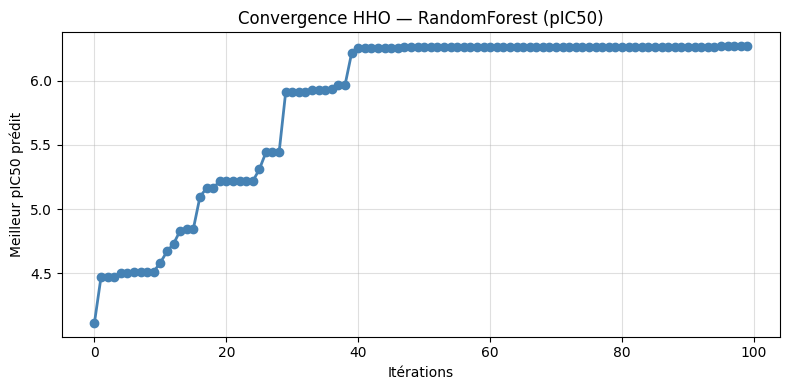

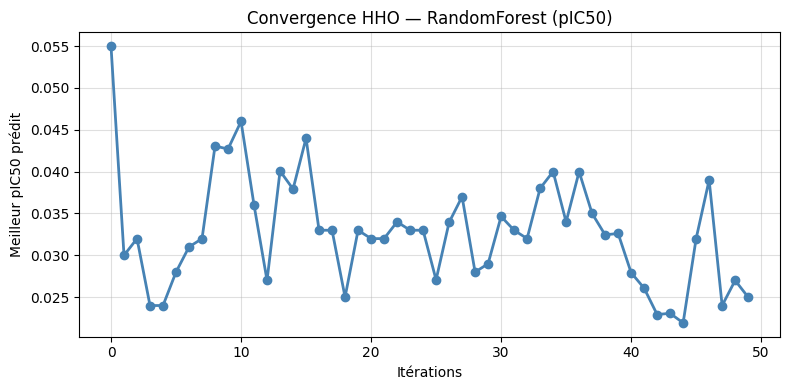

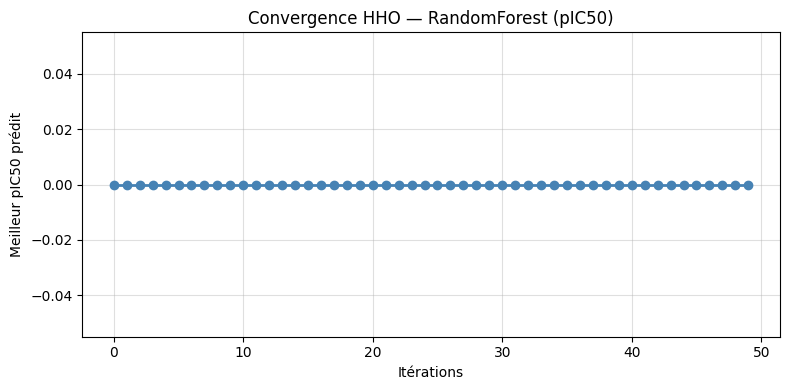

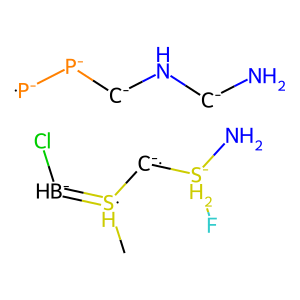

In [36]:
print(f"\nMeilleure molécule : {best_ml}")
print(f"Meilleur pIC50     : {-score_ml:.4f}")
print(f"Entrées cache      : {len(fitness_cache)}")

plt.figure(figsize=(8, 4))
plt.plot([-s for s in curve_ml], linewidth=2, color='steelblue', marker='o')
plt.title('Convergence HHO — RandomForest (pIC50)')
plt.xlabel('Itérations')
plt.ylabel('Meilleur pIC50 prédit')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot([t for t in time_curve], linewidth=2, color='steelblue', marker='o')
plt.title('Convergence HHO — RandomForest (pIC50)')
plt.xlabel('Itérations')
plt.ylabel('Meilleur pIC50 prédit')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot([n for n in cache_curve], linewidth=2, color='steelblue', marker='o')
plt.title('Convergence HHO — RandomForest (pIC50)')
plt.xlabel('Itérations')
plt.ylabel('Meilleur pIC50 prédit')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

mol_ml = Chem.MolFromSmiles(best_ml)
if mol_ml:
    display(Draw.MolToImage(mol_ml, size=(300, 300)))

### **Simulation**

In [54]:
num_sim = 2
num_iter = 20
metrics_df = pd.DataFrame()
pIC50_tracking = []
time_tracking = []
num_mol_checked_tracking = []

init_pop_meth_functions = {
    "hardcoded": lambda: hardcoded_init_population(),
    "randomly generated": lambda: generate_random_smiles(6, 20)
}

for key, method in init_pop_meth_functions.items():
    for i in range(num_sim):
        print("=" * 60)
        print(f"Simulation {i}")
        print("=" * 60)

        best_ml, score_ml, curve_ml, time_curve, cache_curve = hho_discrete(
            obj_func=ml_smiles_fitness,
            initial_population=method(),
            max_iter=num_iter
        )
        row = {
            "method": key,
            "simulation": i,
            "curve": [-v for v in curve_ml],
            "time_curve": time_curve,
            "cache_curve": cache_curve
        }

        metrics_df = pd.concat([metrics_df, pd.DataFrame([row])], ignore_index=True)

Simulation 0
iteration: 0
  Itération 1/20 | Meilleur pIC50 = 5.2305 | Molécule = C.CCCCCCNC(=O)C(C)C
Iteration time cons : 2.0537
iteration: 1
  Itération 2/20 | Meilleur pIC50 = 5.4188 | Molécule = C[SH](C)C(=O)NCCCO.N
Iteration time cons : 1.8174
iteration: 2
  Itération 3/20 | Meilleur pIC50 = 5.4296 | Molécule = C[SH](F)C(=O)NCCCO.N
Iteration time cons : 1.5766
iteration: 3
  Itération 4/20 | Meilleur pIC50 = 5.4296 | Molécule = C[SH](F)C(=O)NCCCO.N
Iteration time cons : 1.9278
iteration: 4
  Itération 5/20 | Meilleur pIC50 = 5.4336 | Molécule = C[SH](F)C(=O)NCCCO.F
Iteration time cons : 1.1997
iteration: 5
  Itération 6/20 | Meilleur pIC50 = 5.4336 | Molécule = C[SH](F)C(=O)NCCCO.F
Iteration time cons : 1.485
iteration: 6
  Itération 7/20 | Meilleur pIC50 = 5.4336 | Molécule = C[SH](F)C(=O)NCCCO.F
Iteration time cons : 1.5431
iteration: 7
  Itération 8/20 | Meilleur pIC50 = 5.4750 | Molécule = CCCNC(=O)[SH2](F)Cl.F
Iteration time cons : 1.424
iteration: 8
  Itération 9/20 | Meill

In [61]:
import numpy as np

final_metrics = []

for method, group in metrics_df.groupby("method"):

    all_curves = np.concatenate(group["curve"].values)
    all_times = np.concatenate(group["time_curve"].values)
    all_cache = np.concatenate(group["cache_curve"].values)

    final_metrics.append({
        "method": method,
        "num_Iterations": num_iter,
        "num_simulations": num_sim,

        # performance
        "min_pIC50": np.min(all_curves),
        "avg_pIC50": np.mean(all_curves),
        "max_pIC50": np.max(all_curves),

        # efficiency
        "min_time": np.min(all_times),
        "avg_time": np.mean(all_times),
        "total_time": np.sum(all_times),

        # exploration
        "avg_molecules_checked": np.mean(all_cache),
        "total_molecules_checked": np.sum(all_cache)
    })

final_df = pd.DataFrame(final_metrics)
final_df.to_excel("Simulation_metrics.xlsx")

In [62]:
final_df

,method,num_Iterations,num_simulations,min_pIC50,avg_pIC50,max_pIC50,min_time,avg_time,total_time,avg_molecules_checked,total_molecules_checked
0,hardcoded,20,2,5.230498,5.660330,5.912736,0.726229,1.518981,60.759230,38.075,1523
1,randomly generated,20,2,4.039217,4.798957,5.739083,0.259311,0.572395,22.895817,14.625,585


In [63]:
# pIC50_df = pd.DataFrame([list(row) for row in zip(*pIC50_tracking)])
# time_df = pd.DataFrame([list(row) for row in zip(*time_tracking)])
# mol_check_df = pd.DataFrame([list(row) for row in zip(*num_mol_checked_tracking)])

In [64]:
# pIC50_df